# Notebook 04 — Preprocesamiento e Imputacion

**Proyecto de Grado — Maestria en Ciencia de Datos**
**Pontificia Universidad Javeriana Cali — Grupo 8**
**Autores:** Laura Garcia Salamanca, Daniel Sebastian Rosero Usama, Juan Villalobos Mora

---

## Estrategia de imputacion

La irradiancia solar exhibe dos regimenes fisicamente distintos:

**Regimen nocturno (horas 0-5 y 19-23):** RS = 0 por ausencia de radiacion solar.
La imputacion es determinista: cualquier NaN nocturno se asigna a 0.

**Regimen diurno (horas 6-18):** Se aplican tres tecnicas independientes.
Para la Tecnica 3 (Kalman) se estratifica por longitud de gap:
- Gap corto (<= 2 horas = 24 intervalos de 5 min): Filtro de Kalman.
  El EM tiene suficientes observaciones validas para estimar Q y R.
- Gap largo (> 2 horas o dia completo sin datos): Media climatologica
  hora x mes como fallback. Kalman con EM degenerara si no hay
  observaciones suficientes en el segmento diario.

**RS > 1400 W/m2:** Se conservan los 55 registros. El fenomeno de
cloud enhancement (realce por nubes) es fisicamente plausible en
zonas tropicales montanosas como Pasto. Umbral de descarte: 1600 W/m2.

## Contenido
1. Carga y configuracion
2. Clasificacion nocturno/diurno y correcciones previas
3. Imputacion nocturna (RS = 0)
4. Tecnica 1: Interpolacion lineal (limite 2h)
5. Tecnica 2: Media climatologica horaria
6. Tecnica 3: Kalman estratificado por longitud de gap
7. Integracion NASA POWER y variables derivadas
8. Comparacion de tecnicas
9. Guardado de datasets finales
10. Analisis descriptivo post-preprocesamiento


---
## Cambios de la revision (septiembre de 2026)

**Indice de claridad.** El calculo del indice dentro de `agregar_variables()` exige ahora un
minimo de 20 W/m2 al denominador. Antes se le asignaba cero al indice cuando la irradiancia de
cielo despejado tendia a cero, en el amanecer y el ocaso; ese cero significa "cielo cubierto" y
lo que ocurria era "no hay denominador". Los faltantes resultantes se rellenan propagando el
valor valido mas cercano dentro del mismo dia.

**Por que importa.** El indice no es solo un descriptor: es una de las dieciocho variables que
entran al modelo en la configuracion V3. Corregirlo solo en el texto y dejar el defecto en los
datos habria significado que el documento describe un indice y el modelo usa otro.

**Que hay que hacer.** Ejecutar el cuaderno entero. Regenera los tres `dataset_final_*.csv`.
Despues hay que reejecutar los cuadernos 04, 05 y 06.
---

In [ ]:
# 0. Importaciones
!pip install pandas numpy matplotlib seaborn pykalman scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import subprocess
import os
import warnings
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from pykalman import KalmanFilter

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

# Umbral maximo de gap para aplicar Kalman (en numero de intervalos de 5 min)
# 24 intervalos x 5 min = 2 horas
KALMAN_GAP_MAX = 24

# El estilo de las figuras (paleta y tamanos de letra) se define en la celda
# siguiente, la celda de estilo, para que sea identico en los 11 cuadernos.
print('Librerias importadas:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print('Umbral Kalman gap max:', KALMAN_GAP_MAX, 'intervalos =', KALMAN_GAP_MAX*5, 'min')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.1/252.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 6.4 MB/s eta 0:00:00
Librerias importadas: 2026-09-09 21:10:30
Umbral Kalman gap max: 24 intervalos = 120 min


### Estilo unico de figuras

Esta celda fija la **paleta de colores** y los **tamanos de letra** de todas las figuras del cuaderno. Es la misma celda en los once cuadernos, de modo que cualquier figura del trabajo de grado sale con el mismo aspecto.


In [ ]:
# @@ESTILO_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  ESTILO UNICO DE FIGURAS DEL TRABAJO DE GRADO
#  Esta celda define la paleta y la tipografia de TODAS las figuras.
#  Es identica en los 11 cuadernos: cambiarla aqui cambia solo este cuaderno,
#  por eso si se modifica hay que modificarla en todos.
#
#  Paleta categorica anclada en el azul. Validada con el verificador de
#  accesibilidad de color (separacion OKLab bajo protanopia y deuteranopia,
#  piso de croma, banda de luminosidad y contraste contra fondo blanco):
#  todos los pares de colores pasan, no solo los contiguos.
# =============================================================================
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler
try:
    import seaborn as sns
except Exception:
    sns = None

# --- 1. Paleta categorica (orden FIJO: la ranura 1 es siempre la serie principal)
C_AZUL    = '#0C60A3'   # ranura 1 - serie principal / observado / T1 / V1
C_AMBAR   = '#D4771A'   # ranura 2 - segunda serie / modelo / T2 / V2
C_CELESTE = '#269AE6'   # ranura 3 - tercera serie / T3 / V3
C_TEJA    = '#963E35'   # ranura 4 - cuarta serie
C_VERDEAZ = '#0D8F73'   # ranura 5 - quinta serie
PALETA_TG = [C_AZUL, C_AMBAR, C_CELESTE, C_TEJA, C_VERDEAZ]

# --- 2. Tonos de apoyo de la rampa azul (rellenos, bandas, sombreados)
C_AZUL_CLARO  = '#81B4EA'
C_AZUL_MEDIO  = '#5A9BDC'
C_AZUL_OSCURO = '#0A3765'

# --- 3. Tinta neutra: texto, ejes, lineas de referencia. NUNCA es una serie.
C_TEXTO      = '#1A1A1A'
C_GRIS       = '#6E6E6E'
C_GRIS_CLARO = '#C9C9C9'

# --- 4. Mapas de color continuos
#   'tg_azul' : secuencial de un solo tono, claro -> oscuro (magnitudes)
#   'tg_div'  : divergente azul <-> teja con gris neutro en el centro
#               (mantiene la lectura de 'RdBu_r': negativo azul, positivo calido)
_SECUENCIAL = ['#F4F9FF', '#D8E8FA', '#B4D2F4', '#81B4EA', '#5A9BDC',
               '#3581C9', '#1667AC', '#0B4E89', '#0A3765']
_DIVERGENTE = ['#0A3765', '#1667AC', '#5A9BDC', '#AFCEEC', '#F2F1EF',
               '#EFC9AC', '#DC9A5A', '#B4642C', '#7E3A2C']
CMAP_SEC = LinearSegmentedColormap.from_list('tg_azul', _SECUENCIAL)
CMAP_DIV = LinearSegmentedColormap.from_list('tg_div',  _DIVERGENTE)

def _registrar_cmap(cm_obj):
    """Registra el mapa por nombre para poder usar cmap='tg_azul'."""
    try:
        mpl.colormaps.register(cm_obj, force=True)          # matplotlib >= 3.6
    except Exception:
        try:
            mpl.cm.register_cmap(cmap=cm_obj)               # matplotlib antiguo
        except Exception:
            pass

for _c in (CMAP_SEC, CMAP_DIV):
    _registrar_cmap(_c)

def escala_azul(n, ini=0.375, fin=1.0):
    """n colores tomados de la rampa azul. Para variables ORDENADAS (anios,
    meses, horizontes): el orden se lee en el tono, de claro a oscuro."""
    if n <= 1:
        return [C_AZUL]
    paso = (fin - ini) / (n - 1)
    return [CMAP_SEC(ini + i * paso) for i in range(n)]

# --- 6. Eje X de fechas legible ----------------------------------------------
import matplotlib.dates as mdates

def eje_fechas(ax):
    """Ajusta el eje X de fechas al rango real de la serie: anios cuando abarca
    anios, meses cuando abarca meses. Evita que se repita la misma etiqueta
    ('2023 2023 2023 ...') cuando el periodo es corto."""
    loc = mdates.AutoDateLocator(minticks=4, maxticks=9)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    return ax

# --- 7. Trazo por serie: si dos curvas se superponen, el trazo las separa -----
ESTILOS_TG = ['-', '--', ':', '-.', (0, (5, 1, 1, 1))]
TRAZO = {'T1': '-', 'T2': '--', 'T3': ':',
         'V1': '-', 'V2': '--', 'V3': ':'}

# --- 5. Tipografia: tamanos grandes para que la figura se lea en el PDF impreso
TAM_BASE = 13          # texto general dentro de la figura
TAM_EJE  = 14          # etiquetas de los ejes X e Y
TAM_TICK = 12          # numeros de los ejes
TAM_TIT  = 14.5        # titulo del panel
TAM_LEY  = 12          # leyenda

plt.rcParams.update({
    # --- color
    'axes.prop_cycle'   : cycler(color=PALETA_TG),
    'image.cmap'        : 'tg_azul',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'savefig.facecolor' : 'white',
    # --- tipografia (lo que pidio la revision: ejes y etiquetas legibles)
    'font.family'       : 'sans-serif',
    'font.size'         : TAM_BASE,
    'axes.titlesize'    : TAM_TIT,
    'axes.labelsize'    : TAM_EJE,
    'axes.titleweight'  : 'bold',
    'axes.labelweight'  : 'normal',
    'xtick.labelsize'   : TAM_TICK,
    'ytick.labelsize'   : TAM_TICK,
    'legend.fontsize'   : TAM_LEY,
    'legend.title_fontsize': TAM_LEY,
    'figure.titlesize'  : TAM_TIT + 1.5,
    # --- trazos y ejes discretos
    'lines.linewidth'   : 1.8,
    'lines.markersize'  : 5.5,
    'axes.linewidth'    : 0.9,
    'axes.edgecolor'    : '#8A8A8A',
    'axes.labelcolor'   : C_TEXTO,
    'text.color'        : C_TEXTO,
    'xtick.color'       : '#8A8A8A',
    'ytick.color'       : '#8A8A8A',
    'xtick.labelcolor'  : C_TEXTO,
    'ytick.labelcolor'  : C_TEXTO,
    'xtick.major.width' : 0.9,
    'ytick.major.width' : 0.9,
    'grid.color'        : C_GRIS_CLARO,
    'grid.linewidth'    : 0.7,
    'grid.alpha'        : 0.55,
    'legend.frameon'    : True,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '#C9C9C9',
    # --- exportacion para Overleaf: el texto viaja como texto dentro del PDF
    'figure.dpi'        : 110,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'pdf.fonttype'      : 42,
    'ps.fonttype'       : 42,
    'svg.fonttype'      : 'path',
})

if sns is not None:
    sns.set_palette(PALETA_TG)

print('Estilo de figuras aplicado.')
print(f'  Paleta categorica: {", ".join(PALETA_TG)}')
print(f'  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)')
print(f'  Tamanos: ejes {TAM_EJE} pt, numeros {TAM_TICK} pt, leyenda {TAM_LEY} pt')


Estilo de figuras aplicado.
  Paleta categorica: #0C60A3, #D4771A, #269AE6, #963E35, #0D8F73
  Mapas continuos:   tg_azul (secuencial), tg_div (divergente)
  Tamanos: ejes 14 pt, numeros 12 pt, leyenda 12 pt


In [ ]:
# @@RUTAS_TG@@  (marca unica: no editar esta linea)
# =============================================================================
#  DONDE VIVE EL PROYECTO
#
#  En el Drive hay mas de una copia del proyecto: la del semestre anterior y la
#  actual. Antes cada cuaderno buscaba un archivo de datos por todo el Drive y
#  se quedaba con el PRIMERO que aparecia, que no siempre era el de la carpeta
#  correcta; por eso 'figuras', 'figuras_PDF' y 'figuras_SVG' se crearon en la
#  carpeta vieja.
#
#  Ahora la carpeta del proyecto se decide UNA sola vez y de forma explicita:
#  es la carpeta cuyo nombre esta en NOMBRE_CARPETA y cuya ruta contiene
#  CARPETA_PROYECTO. TODO lo que el cuaderno escriba va ahi.
#
#  Si algun dia mueves el proyecto (por ejemplo a 'Proyecto Aplicado IV'),
#  cambias UNA linea: CARPETA_PROYECTO. Y la cambias en los once cuadernos.
# =============================================================================
import os
import subprocess

CARPETA_PROYECTO = 'Proyecto Aplicado III'      # <-- la carpeta actual del semestre
NOMBRE_CARPETA   = 'Codigos Trabajo de Grado'   # <-- nombre de la carpeta de codigo
RAIZ_DRIVE       = '/content/drive/MyDrive'

# Rutas que nunca se usan como carpeta del proyecto, aunque coincidan de nombre.
EXCLUIR_RUTAS = ['/anterior/', '/.Trash', '/.shortcut-targets-by-id/',
                 '/copia de ', '/copy of ']


def _montar_drive():
    try:
        from google.colab import drive
    except Exception:
        return
    if not os.path.isdir(RAIZ_DRIVE):
        drive.mount('/content/drive')
    else:
        print('Drive ya montado.')


def _find(patron, tipo='f', maxdepth=None, raiz=RAIZ_DRIVE, timeout=300):
    cmd = ['find', raiz]
    if maxdepth is not None:
        cmd += ['-maxdepth', str(maxdepth)]
    cmd += ['-type', tipo, '-name', patron]
    try:
        res = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
    except Exception:
        return []
    return [r for r in res.stdout.strip().split('\n') if r]


def _excluida(ruta):
    r = ruta.lower()
    return any(x.lower() in r for x in EXCLUIR_RUTAS)


def localizar_proyecto():
    """Devuelve la carpeta del proyecto. Falla con un mensaje claro si no la
    encuentra o si encuentra mas de una: nunca elige a ciegas."""
    _montar_drive()

    candidatas = _find(NOMBRE_CARPETA, tipo='d', maxdepth=8)
    if not candidatas:
        candidatas = _find(NOMBRE_CARPETA, tipo='d')
    # Segunda pista: cualquier carpeta que contenga los cuadernos de la cadena.
    for nb in _find('0*_*REVISADO.ipynb', tipo='f', maxdepth=9):
        d = os.path.dirname(nb)
        if d not in candidatas:
            candidatas.append(d)

    validas   = [c for c in candidatas if CARPETA_PROYECTO in c and not _excluida(c)]
    descartes = [c for c in candidatas if c not in validas]

    if len(validas) == 1:
        print(f'Carpeta del proyecto: {validas[0]}')
        if descartes:
            print(f'  ({len(descartes)} carpeta(s) descartada(s) por no estar en '
                  f'"{CARPETA_PROYECTO}")')
        return validas[0]

    print('\n' + '=' * 78)
    print('NO SE PUDO DECIDIR LA CARPETA DEL PROYECTO')
    print('=' * 78)
    print(f'  Se busca:  una carpeta "{NOMBRE_CARPETA}" cuya ruta contenga '
          f'"{CARPETA_PROYECTO}"')
    print(f'  Encontradas: {len(candidatas)}')
    for c in candidatas:
        marca = 'SIRVE     ' if c in validas else 'descartada'
        print(f'    [{marca}] {c}')
    print()
    if not validas:
        print('  Que hacer: comprueba el nombre exacto de la carpeta en Drive y ajusta')
        print('  arriba CARPETA_PROYECTO o NOMBRE_CARPETA. Si moviste el proyecto,')
        print('  recuerda cambiarlo en los once cuadernos.')
    else:
        print('  Hay varias carpetas que sirven. Escribe arriba una CARPETA_PROYECTO')
        print('  mas especifica, por ejemplo la ruta completa desde MyDrive.')
    print('=' * 78 + '\n')
    raise FileNotFoundError(
        f'No hay exactamente una carpeta "{NOMBRE_CARPETA}" bajo "{CARPETA_PROYECTO}".')


# --- La carpeta del proyecto y todo lo que cuelga de ella --------------------
RUTA_BASE     = localizar_proyecto()
RUTA_DATOS    = os.path.join(RUTA_BASE, 'datos')
RUTA_ARRAYS   = os.path.join(RUTA_DATOS, 'arrays')
RUTA_MODELOS  = os.path.join(RUTA_BASE, 'modelos')
RUTA_RES      = os.path.join(RUTA_BASE, 'resultados')
RUTA_FIGS     = os.path.join(RUTA_BASE, 'figuras')       # PNG
RUTA_FIGS_SVG = os.path.join(RUTA_BASE, 'figuras_SVG')   # SVG
RUTA_FIGS_PDF = os.path.join(RUTA_BASE, 'figuras_PDF')   # PDF, el de Overleaf

for _d in (RUTA_DATOS, RUTA_ARRAYS, RUTA_MODELOS, RUTA_RES,
           RUTA_FIGS, RUTA_FIGS_SVG, RUTA_FIGS_PDF):
    os.makedirs(_d, exist_ok=True)


def archivo_de_datos(nombre, obligatorio=True, pista=''):
    """Localiza un archivo de ENTRADA.

    Primero lo busca dentro de la carpeta del proyecto. Solo si no esta lo busca
    en el resto del Drive, y en ese caso avisa en grande: significa que ese
    archivo se quedo en la carpeta vieja y conviene copiarlo.
    Lo que el cuaderno ESCRIBE nunca sale de la carpeta del proyecto.
    """
    for sub in ('datos', os.path.join('datos', 'arrays'), '', 'resultados', 'modelos'):
        cand = os.path.join(RUTA_BASE, sub, nombre) if sub else os.path.join(RUTA_BASE, nombre)
        if os.path.exists(cand):
            return cand

    fuera = _find(nombre, tipo='f')
    if fuera:
        fuera.sort(key=lambda r: os.path.getmtime(r), reverse=True)
        elegido = fuera[0]
        print('\n' + '!' * 78)
        print(f'AVISO: "{nombre}" no esta en la carpeta del {CARPETA_PROYECTO}.')
        print(f'  Se leera de: {elegido}')
        print(f'  Copialo a  : {RUTA_DATOS}')
        print('  Mientras siga en dos sitios, corres el riesgo de leer una version vieja.')
        print('!' * 78 + '\n')
        return elegido

    if obligatorio:
        raise FileNotFoundError(
            f'No se encontro "{nombre}" ni en la carpeta del proyecto ni en el resto '
            f'del Drive.\n  Carpeta del proyecto: {RUTA_BASE}\n  {pista}')
    return None


print(f'  datos      : {RUTA_DATOS}')
print(f'  figuras    : {RUTA_FIGS} (+ _SVG y _PDF)')
print(f'  modelos    : {RUTA_MODELOS}')
print(f'  resultados : {RUTA_RES}')

# --- Entradas propias de este cuaderno ---------------------------------------
RUTA_CSV  = archivo_de_datos('Datos_2013_2026_completo.csv',
                             pista='Es el CSV de la estacion CESMAG, sin procesar.')
RUTA_NASA = archivo_de_datos('nasa_power_pasto_2013_2026_horario.csv',
                             obligatorio=False,
                             pista='Lo genera el cuaderno 00.')
print('  RUTA_CSV  :', RUTA_CSV)
print('  RUTA_NASA :', RUTA_NASA)


Mounted at /content/drive
Carpeta del proyecto: /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado
  datos      : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/datos
  figuras    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras (+ _SVG y _PDF)
  modelos    : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/modelos
  resultados : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/resultados
  RUTA_CSV  : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/Datos_2013_2026_completo.csv
  RUTA_NASA : /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de G

### Figuras en PNG, SVG y PDF

**Añadido en la revisión.** Todas las figuras de este cuaderno se guardan ahora en los tres
formatos, con el mismo nombre y en tres carpetas paralelas: `figuras/` para el PNG,
`figuras_SVG/` para el vectorial editable y `figuras_PDF/` para el que se incluye en Overleaf.

En LaTeX se incluye sin extensión, y así el compilador elige el formato adecuado:

```latex
\includegraphics[width=\linewidth]{figuras_PDF/fig_01b_distribucion}
```

In [ ]:
# --- Guardado de figuras en los tres formatos ----------------------------
#
# El documento se compila en Overleaf, que incluye las figuras en PDF, pero
# conviene tener tambien el SVG (editable) y el PNG (vista rapida y para
# presentaciones). Antes cada cuaderno guardaba en un formato distinto: unos en
# SVG, otros en PDF, otros en PNG. Ahora todos usan esta funcion y producen los
# tres, con el mismo nombre, en tres carpetas paralelas:
#
#   figuras/       nombre.png   300 ppp
#   figuras_SVG/   nombre.svg   vectorial editable
#   figuras_PDF/   nombre.pdf   el que se incluye en LaTeX
#
# En LaTeX basta con \includegraphics{figuras_PDF/nombre} sin extension.
import os
import matplotlib.pyplot as plt

FORMATOS_FIGURA = (
    ('RUTA_FIGS',     'png', {'dpi': 300}),
    ('RUTA_FIGS_SVG', 'svg', {}),
    ('RUTA_FIGS_PDF', 'pdf', {}),
)


def guardar_figura(fig, nombre, verbose=True):
    """Guarda la figura en PNG, SVG y PDF. 'nombre' va SIN extension."""
    if fig is None:
        fig = plt.gcf()
    base = os.path.splitext(os.path.basename(str(nombre)))[0]
    rutas = []
    for var, ext, extra in FORMATOS_FIGURA:
        carpeta = globals().get(var)
        if carpeta is None:
            continue
        os.makedirs(carpeta, exist_ok=True)
        ruta = os.path.join(carpeta, f'{base}.{ext}')
        fig.savefig(ruta, bbox_inches='tight', **extra)
        rutas.append(ruta)
    if verbose:
        print(f'  Figura guardada: {base}.png, .svg y .pdf')
    return rutas


print('Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.')
for _v in ('RUTA_FIGS', 'RUTA_FIGS_SVG', 'RUTA_FIGS_PDF'):
    print(f'  {_v:<14} {globals().get(_v)}')

Funcion guardar_figura lista: cada figura se guarda en PNG, SVG y PDF.
  RUTA_FIGS      /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras
  RUTA_FIGS_SVG  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_SVG
  RUTA_FIGS_PDF  /content/drive/MyDrive/Maestría Ciencia de Datos Tercer Semestre/Proyecto Aplicado III/Codigos Trabajo de Grado/figuras_PDF


In [ ]:
# 1.1 Carga del dataset CESMAG
with open(RUTA_CSV, 'r', encoding='utf-8', errors='replace') as f:
    lineas = [f.readline().strip() for _ in range(3)]
cab = lineas[0]
SEP = ';' if cab.count(';') > cab.count(',') else ','
DEC = ',' if (SEP == ';' and ',' in lineas[1]) else '.'

print('Cargando dataset CESMAG...')
df_raw = pd.read_csv(
    RUTA_CSV, sep=SEP, decimal=DEC,
    parse_dates=['DateTime'], index_col='DateTime', encoding='utf-8'
)
df_raw.columns    = ['RS']
df_raw.index.name = 'timestamp'
df_raw.sort_index(inplace=True)
df_raw['RS'] = pd.to_numeric(df_raw['RS'], errors='coerce')

print(f'Registros : {len(df_raw):,}')
print(f'Faltantes : {df_raw["RS"].isnull().sum():,}  ({df_raw["RS"].isnull().mean()*100:.3f}%)')
print(f'Periodo   : {df_raw.index.min()} -> {df_raw.index.max()}')

Cargando dataset CESMAG...
Registros : 1,330,560
Faltantes : 225,244  (16.929%)
Periodo   : 2013-08-01 00:00:00 -> 2026-03-25 23:55:00


In [ ]:
# 2. Clasificacion y correcciones previas
HORA_INICIO_DIURNO = 6
HORA_FIN_DIURNO    = 18

horas            = df_raw.index.hour
mascara_diurno   = (horas >= HORA_INICIO_DIURNO) & (horas <= HORA_FIN_DIURNO)
mascara_nocturno = ~mascara_diurno

# Correccion: RS < 0 -> 0
n_neg = (df_raw['RS'] < 0).sum()
df_raw.loc[df_raw['RS'] < 0, 'RS'] = 0.0

# Correccion: RS > 0 en horas nocturnas -> NaN para reclasificacion
n_noc_pos = ((df_raw['RS'] > 0) & mascara_nocturno).sum()
df_raw.loc[(df_raw['RS'] > 0) & mascara_nocturno, 'RS'] = np.nan

# PARCHE DE LA REVISION: aqui, y solo aqui, se sabe que valores vienen del
# sensor y cuales van a inventarse. Se guarda esa marca y viaja con el conjunto
# hasta los cuadernos 06 y 07, para poder reportar el error del modelo tambien
# sobre los puntos REALMENTE MEDIDOS. Sin ella, el RMSE del modelo se calcula en
# parte contra valores climatologicos, cuyo propio error de validacion por
# ocultamiento (cuaderno 09) es de unos 210 W/m2.
MASK_OBSERVADO = df_raw['RS'].notna().copy()
print(f'  Puntos medidos por el sensor    : {MASK_OBSERVADO.sum():,} '
      f'({MASK_OBSERVADO.mean()*100:.2f} %)')
print(f'  Puntos que se van a rellenar    : {(~MASK_OBSERVADO).sum():,}')

n_falt_noc  = df_raw.loc[mascara_nocturno,  'RS'].isnull().sum()
n_falt_diur = df_raw.loc[mascara_diurno,    'RS'].isnull().sum()

print('CORRECCIONES PREVIAS')
print(f'  RS < 0 -> 0                    : {n_neg:,}')
print(f'  RS > 0 nocturno -> NaN         : {n_noc_pos:,}')
print()
print('FALTANTES POR FRANJA')
print(f'  Nocturna  (0-5h, 19-23h) : {n_falt_noc:>7,}  ({n_falt_noc/mascara_nocturno.sum()*100:.2f}%)')
print(f'  Diurna    (6-18h)        : {n_falt_diur:>7,}  ({n_falt_diur/mascara_diurno.sum()*100:.2f}%)')

# Diagnostico de gaps diurnos por longitud
# Identificar bloques consecutivos de NaN diurnos
serie_diurna_diag = df_raw.loc[mascara_diurno, 'RS'].copy()
es_nan            = serie_diurna_diag.isnull().astype(int)
bloques           = (es_nan != es_nan.shift()).cumsum()
longitudes_gaps   = es_nan[es_nan == 1].groupby(bloques[es_nan == 1]).sum()

n_gaps_cortos = (longitudes_gaps <= KALMAN_GAP_MAX).sum()
n_gaps_largos = (longitudes_gaps >  KALMAN_GAP_MAX).sum()
pts_cortos    = longitudes_gaps[longitudes_gaps <= KALMAN_GAP_MAX].sum()
pts_largos    = longitudes_gaps[longitudes_gaps >  KALMAN_GAP_MAX].sum()

print()
print('DIAGNOSTICO DE GAPS DIURNOS')
print(f'  Gaps cortos (<={KALMAN_GAP_MAX} intervalos, <=2h) : {n_gaps_cortos:,}  ({pts_cortos:,} puntos -> Kalman)')
print(f'  Gaps largos (>{KALMAN_GAP_MAX}  intervalos, >2h)  : {n_gaps_largos:,}  ({pts_largos:,} puntos -> Media clim.)')

  Puntos medidos por el sensor    : 1,105,211 (83.06 %)
  Puntos que se van a rellenar    : 225,349
CORRECCIONES PREVIAS
  RS < 0 -> 0                    : 0
  RS > 0 nocturno -> NaN         : 105

FALTANTES POR FRANJA
  Nocturna  (0-5h, 19-23h) :   1,552  (0.25%)
  Diurna    (6-18h)        : 223,797  (31.05%)

DIAGNOSTICO DE GAPS DIURNOS
  Gaps cortos (<=24 intervalos, <=2h) : 67  (522 puntos -> Kalman)
  Gaps largos (>24  intervalos, >2h)  : 164  (223,275 puntos -> Media clim.)


In [ ]:
# 3. Imputacion nocturna: RS = 0 (determinista)
df_base = df_raw.copy()
n_imp_noc = df_base.loc[mascara_nocturno, 'RS'].isnull().sum()
df_base.loc[mascara_nocturno, 'RS'] = df_base.loc[mascara_nocturno, 'RS'].fillna(0.0)

print('IMPUTACION NOCTURNA')
print(f'  Imputados con 0     : {n_imp_noc:,}')
print(f'  NaN nocturnos rest. : {df_base.loc[mascara_nocturno, "RS"].isnull().sum()}  (debe ser 0)')
print(f'  NaN diurnos rest.   : {df_base.loc[mascara_diurno, "RS"].isnull().sum():,}  (pendientes)')

IMPUTACION NOCTURNA
  Imputados con 0     : 1,552
  NaN nocturnos rest. : 0  (debe ser 0)
  NaN diurnos rest.   : 223,797  (pendientes)


In [ ]:
# Precalcular media climatologica hora x mes (se reutiliza en T2 y como fallback de T3)
# Se calcula sobre los valores validos del dataset original (antes de cualquier imputacion)
df_aux = df_raw.copy()
df_aux['hora'] = df_aux.index.hour
df_aux['mes']  = df_aux.index.month

media_clim_df = (
    df_aux[df_aux['RS'].notna()]
    .groupby(['hora', 'mes'])['RS']
    .mean()
    .reset_index()
    .rename(columns={'RS': 'media_clim'})
)

# Convertir a dict para lookup rapido: (hora, mes) -> valor
dict_media_clim = {
    (row['hora'], row['mes']): row['media_clim']
    for _, row in media_clim_df.iterrows()
}

def imputar_con_media_clim(serie):
    """Imputa NaN usando la media climatologica hora x mes."""
    s = serie.copy()
    mascara = s.isnull()
    for ts in s.index[mascara]:
        clave = (ts.hour, ts.month)
        s.at[ts] = dict_media_clim.get(clave, 0.0)
    return s.clip(lower=0.0, upper=1600.0)

media_clim_df.to_csv(
    os.path.join(RUTA_DATOS, 'tabla_02_medias_climatologicas.csv'), index=False
)
print(f'Medias climatologicas calculadas: {len(media_clim_df)} combinaciones hora x mes')
print('Guardado: tabla_02_medias_climatologicas.csv')

Medias climatologicas calculadas: 288 combinaciones hora x mes
Guardado: tabla_02_medias_climatologicas.csv


In [ ]:
# 4. Tecnica 1 — Interpolacion lineal con limite de 2 horas
#
# Fundamento: la interpolacion lineal estima valores faltantes asumiendo
# variacion proporcional al tiempo entre los puntos validos adyacentes.
# El parametro limit=24 restringe la interpolacion a gaps de hasta 2 horas
# (24 intervalos x 5 min). Para gaps mas largos, el valor queda NaN y
# se imputa con la media climatologica como fallback, evitando las
# mesetas artificiales observadas en la version anterior.

df_t1 = df_base.copy()

# Aplicar solo en franja diurna con limite de 24 intervalos
serie_diurna = df_t1.loc[mascara_diurno, 'RS'].copy()
serie_interp = serie_diurna.interpolate(
    method='time',
    limit=KALMAN_GAP_MAX,          # maximo 24 intervalos consecutivos
    limit_direction='both'
)
df_t1.loc[mascara_diurno, 'RS'] = serie_interp

# Fallback con media climatologica para gaps que superaron el limite
n_restantes_t1 = df_t1['RS'].isnull().sum()
if n_restantes_t1 > 0:
    df_t1.loc[:, 'RS'] = imputar_con_media_clim(df_t1['RS'])

df_t1['RS'] = df_t1['RS'].clip(lower=0.0, upper=1600.0)

print('TECNICA 1 — INTERPOLACION LINEAL (limite 2h)')
print(f'  Imputados por interpolacion   : {n_falt_diur - n_restantes_t1:,}')
print(f'  Imputados por media clim.     : {n_restantes_t1:,}')
print(f'  NaN restantes                 : {df_t1["RS"].isnull().sum()}  (debe ser 0)')
print(f'  Min / Max / Media RS          : {df_t1["RS"].min():.2f} / {df_t1["RS"].max():.2f} / {df_t1["RS"].mean():.4f} W/m2')

TECNICA 1 — INTERPOLACION LINEAL (limite 2h)
  Imputados por interpolacion   : 7,993
  Imputados por media clim.     : 215,804
  NaN restantes                 : 0  (debe ser 0)
  Min / Max / Media RS          : 0.00 / 1559.00 / 142.8036 W/m2


In [ ]:
# 5. Tecnica 2 — Media climatologica horaria
#
# Fundamento: la media climatologica hora x mes captura la estacionalidad
# doble de la irradiancia (ciclo diario y variacion mensual) sin depender
# de los valores adyacentes. Es equivalente a usar el componente estacional
# de una descomposicion STL como valor de referencia. Robusta para gaps
# de cualquier longitud.

df_t2 = df_base.copy()
df_t2.loc[:, 'RS'] = imputar_con_media_clim(df_t2['RS'])
df_t2['RS'] = df_t2['RS'].clip(lower=0.0, upper=1600.0)

print('TECNICA 2 — MEDIA CLIMATOLOGICA HORARIA')
print(f'  NaN restantes : {df_t2["RS"].isnull().sum()}  (debe ser 0)')
print(f'  Min / Max / Media RS : {df_t2["RS"].min():.2f} / {df_t2["RS"].max():.2f} / {df_t2["RS"].mean():.4f} W/m2')

TECNICA 2 — MEDIA CLIMATOLOGICA HORARIA
  NaN restantes : 0  (debe ser 0)
  Min / Max / Media RS : 0.00 / 1559.00 / 142.6615 W/m2


In [ ]:
# 6. Tecnica 3 — Filtro de Kalman estratificado por longitud de gap
#
# Fundamento: el filtro de Kalman es un estimador recursivo optimo para
# sistemas dinamicos lineales con ruido gaussiano. Modela RS como un
# proceso de estado latente con ecuaciones:
#
#   x_t = x_{t-1} + w_t    (paseo aleatorio, w_t ~ N(0,Q))
#   z_t = x_t + v_t        (observacion directa, v_t ~ N(0,R))
#
# Q y R se estiman por Expectation-Maximization (EM) sobre los valores
# observados del segmento. Para que el EM converja correctamente se
# requieren suficientes observaciones validas.
#
# ESTRATIFICACION:
# - Gap corto (<= 24 intervalos = 2h): suficientes puntos validos en el
#   dia para que el EM estime Q y R con fiabilidad. Se aplica Kalman
#   sobre el dia completo SOLO en franja diurna.
# - Gap largo (> 24 intervalos o dia sin datos): el EM no tiene
#   suficientes observaciones. Se usa media climatologica como fallback.
#
# CORRECCION RESPECTO A VERSION ANTERIOR:
# El segmento procesado por Kalman se restringe estrictamente a la
# franja diurna del dia (6-18h). Incluir horas nocturnas (RS = 0)
# contamina el EM y hace que Q y R converjan a valores casi nulos,
# produciendo estimaciones degeneradas cercanas a cero.

df_t3 = df_base.copy()

def kalman_impute_diurno(serie_diurna_dia):
    """
    Aplica Kalman a la franja diurna de un dia (solo horas 6-18).
    Sustituye unicamente los NaN originales; los valores observados
    no se modifican.

    Parametros:
    -----------
    serie_diurna_dia : pd.Series con indice temporal, solo horas 6-18

    Retorna:
    --------
    pd.Series con NaN imputados
    """
    valores = serie_diurna_dia.values.astype(float)
    n       = len(valores)

    # Si no hay ningun valor valido -> fallback a 0
    # (se reemplazara por media clim. en el paso siguiente)
    if np.all(np.isnan(valores)):
        return pd.Series(np.nan * np.ones(n), index=serie_diurna_dia.index)

    # Media de los valores observados -> estado inicial
    media_obs = np.nanmean(valores)
    var_obs   = np.nanvar(valores) if np.nanvar(valores) > 0 else 1.0

    kf = KalmanFilter(
        transition_matrices   = [[1]],
        observation_matrices  = [[1]],
        transition_covariance = [[var_obs * 0.1]],
        observation_covariance= [[var_obs * 0.5]],
        initial_state_mean    = [media_obs],
        initial_state_covariance = [[var_obs]],
        em_vars=['transition_covariance', 'observation_covariance']
    )

    obs = valores.reshape(-1, 1).copy()

    try:
        kf = kf.em(obs, n_iter=10)
        estados, _ = kf.smooth(obs)
        estimados  = estados.flatten()
    except Exception:
        # Si el EM falla, fallback a interpolacion lineal
        estimados = serie_diurna_dia.interpolate(
            method='time', limit_direction='both'
        ).values

    # Sustituir SOLO los NaN originales
    resultado = serie_diurna_dia.copy()
    nan_mask  = serie_diurna_dia.isnull()
    resultado[nan_mask] = estimados[nan_mask.values]

    return resultado.clip(lower=0.0, upper=1600.0)


# Identificar dias con gaps cortos en franja diurna
# Un dia es elegible para Kalman si su gap maximo diurno <= KALMAN_GAP_MAX
print('Clasificando dias por longitud de gap diurno...')

serie_diurna_base = df_t3.loc[mascara_diurno, 'RS'].copy()
fechas_unicas     = pd.Series(serie_diurna_base.index.date).unique()

dias_kalman      = set()
dias_media_clim  = set()

for fecha in fechas_unicas:
    seg = serie_diurna_base[serie_diurna_base.index.date == fecha]
    if seg.isnull().sum() == 0:
        continue  # dia completo, no requiere imputacion
    if seg.isnull().all():
        dias_media_clim.add(fecha)  # dia sin ningun dato diurno
        continue
    # Calcular longitud del gap mas largo del dia
    es_nan    = seg.isnull().astype(int)
    bloques   = (es_nan != es_nan.shift()).cumsum()
    gaps      = es_nan[es_nan == 1].groupby(bloques[es_nan == 1]).sum()
    gap_max   = gaps.max() if len(gaps) > 0 else 0

    if gap_max <= KALMAN_GAP_MAX:
        dias_kalman.add(fecha)
    else:
        dias_media_clim.add(fecha)

print(f'  Dias con Kalman      : {len(dias_kalman):,}')
print(f'  Dias con Media clim. : {len(dias_media_clim):,}')
print(f'  Dias sin faltantes   : {len(fechas_unicas) - len(dias_kalman) - len(dias_media_clim):,}')

Clasificando dias por longitud de gap diurno...
  Dias con Kalman      : 98
  Dias con Media clim. : 1,523
  Dias sin faltantes   : 2,999


In [ ]:
# Aplicar Kalman a los dias elegibles
print('Aplicando Kalman a dias con gaps cortos...')

n_kalman_aplicados = 0
for i, fecha in enumerate(sorted(dias_kalman)):
    # Extraer SOLO la franja diurna del dia desde serie_diurna_base
    seg_diurno   = serie_diurna_base[serie_diurna_base.index.date == fecha]
    seg_imputado = kalman_impute_diurno(seg_diurno)
    df_t3.loc[seg_imputado.index, 'RS'] = seg_imputado.values
    n_kalman_aplicados += 1

    if n_kalman_aplicados % 200 == 0:
        print(f'  Dias procesados: {n_kalman_aplicados}/{len(dias_kalman)}')

print(f'  Kalman aplicado a {n_kalman_aplicados} dias.')

# Aplicar media climatologica a los dias con gaps largos o sin datos
print('Aplicando media climatologica a dias con gaps largos...')
nan_restantes_t3 = df_t3['RS'].isnull().sum()
if nan_restantes_t3 > 0:
    df_t3.loc[:, 'RS'] = imputar_con_media_clim(df_t3['RS'])

df_t3['RS'] = df_t3['RS'].clip(lower=0.0, upper=1600.0)

n_nan_t3_final = df_t3['RS'].isnull().sum()
print()
print('TECNICA 3 — FILTRO DE KALMAN (estratificado)')
print(f'  Dias con Kalman aplicado      : {len(dias_kalman):,}')
print(f'  Dias con Media clim. fallback : {len(dias_media_clim):,}')
print(f'  NaN restantes                 : {n_nan_t3_final}  (debe ser 0)')
print(f'  Min / Max / Media RS          : {df_t3["RS"].min():.2f} / {df_t3["RS"].max():.2f} / {df_t3["RS"].mean():.4f} W/m2')

Aplicando Kalman a dias con gaps cortos...
  Kalman aplicado a 98 dias.
Aplicando media climatologica a dias con gaps largos...

TECNICA 3 — FILTRO DE KALMAN (estratificado)
  Dias con Kalman aplicado      : 98
  Dias con Media clim. fallback : 1,523
  NaN restantes                 : 0  (debe ser 0)
  Min / Max / Media RS          : 0.00 / 1559.00 / 142.6934 W/m2


In [ ]:
# 7. Integracion NASA POWER y variables derivadas

if RUTA_NASA is None:
    print('ADVERTENCIA: NASA POWER no encontrado. Solo variables temporales.')
    df_nasa_5 = None
else:
    print('Cargando NASA POWER...')
    df_nasa = pd.read_csv(RUTA_NASA, index_col='timestamp_utc', parse_dates=True)
    print(f'  Registros: {len(df_nasa):,} | Variables: {list(df_nasa.columns)}')

    # ---- CORRECCION DE ZONA HORARIA -------------------------------------
    # NASA POWER se descarga con time-standard=UTC, mientras que la serie
    # de la estacion CESMAG esta en hora local de Pasto (UTC-5). Sin este
    # ajuste las variables satelitales quedan desfasadas 5 horas respecto
    # a los fenomenos locales. Colombia no aplica horario de verano, por
    # lo que el desplazamiento es constante en todo el periodo.
    df_nasa.index = df_nasa.index - pd.Timedelta(hours=5)
    df_nasa.index.name = 'timestamp_local'
    print(f'  Ajuste UTC -> hora local (UTC-5) aplicado')
    print(f'  Nuevo periodo: {df_nasa.index.min()} -> {df_nasa.index.max()}')
    # ---------------------------------------------------------------------

    # Interpolar de resolucion horaria a 5 minutos
    idx_5min  = df_t1.index
    df_nasa_5 = (
        df_nasa
        .reindex(df_nasa.index.union(idx_5min))
        .interpolate(method='time')
        .reindex(idx_5min)
        .ffill()
        .bfill()
    )
    print(f'  Interpolado a 5 min: {len(df_nasa_5):,} registros')
    print(f'  NaN tras interpolacion: {df_nasa_5.isnull().sum().sum():,}')

    # Verificacion rapida del ajuste horario
tmp = df_nasa_5.copy()
tmp['RS'] = df_t1['RS']
diurno = tmp[(tmp.index.hour >= 6) & (tmp.index.hour <= 18)]
print('Correlacion RS vs ALLSKY :', round(diurno['RS'].corr(diurno['ALLSKY_SFC_SW_DWN']), 3))
print('Correlacion RS vs SZA    :', round(diurno['RS'].corr(diurno['SZA']), 3))
print('Hora del pico de ALLSKY  :', tmp.groupby(tmp.index.hour)['ALLSKY_SFC_SW_DWN'].mean().idxmax())

Cargando NASA POWER...
  Registros: 111,744 | Variables: ['ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS10M', 'WD10M', 'PS', 'SZA']
  Ajuste UTC -> hora local (UTC-5) aplicado
  Nuevo periodo: 2013-07-31 19:00:00 -> 2026-04-30 18:00:00
  Interpolado a 5 min: 1,330,560 registros
  NaN tras interpolacion: 0
Correlacion RS vs ALLSKY : 0.663
Correlacion RS vs SZA    : -0.66
Hora del pico de ALLSKY  : 11


In [ ]:
# 7.1 Variables temporales ciclicas y derivadas
#
# Variables temporales ciclicas con codificacion sin/cos:
# Las variables periodicas (hora, mes, dia del anio) son ciclicas:
# la hora 23 es adyacente a la 0, diciembre a enero. Codificarlas
# como enteros introduce discontinuidades artificiales. La transformacion
# sin/cos proyecta cada variable sobre un circulo unitario preservando
# la continuidad y permitiendo al modelo capturar la periodicidad:
#
#   sin(2*pi*hora/24)  ,  cos(2*pi*hora/24)

def agregar_variables(df, df_nasa_5=None):
    d = df[['RS']].copy()

    # Variables temporales enteras
    d['hora']       = d.index.hour
    d['minuto']     = d.index.minute
    d['dia_semana'] = d.index.dayofweek
    d['dia_anio']   = d.index.dayofyear
    d['mes']        = d.index.month
    d['anio']       = d.index.year

    # Codificacion ciclica: hora del dia
    min_total     = d['hora'] * 60 + d['minuto']
    d['sin_hora'] = np.sin(2 * np.pi * min_total / (24 * 60))
    d['cos_hora'] = np.cos(2 * np.pi * min_total / (24 * 60))

    # Codificacion ciclica: dia del anio
    d['sin_dia_anio'] = np.sin(2 * np.pi * d['dia_anio'] / 365.25)
    d['cos_dia_anio'] = np.cos(2 * np.pi * d['dia_anio'] / 365.25)

    # Codificacion ciclica: mes
    d['sin_mes'] = np.sin(2 * np.pi * d['mes'] / 12)
    d['cos_mes'] = np.cos(2 * np.pi * d['mes'] / 12)

    # Indicador binario franja diurna
    d['es_diurno'] = ((d['hora'] >= HORA_INICIO_DIURNO) &
                      (d['hora'] <= HORA_FIN_DIURNO)).astype(int)

    # Variables NASA POWER
    if df_nasa_5 is not None:
        for col in df_nasa_5.columns:
            d[col] = df_nasa_5[col].values

        # Indice de claridad KT — PARCHE DE LA REVISION
        #
        # PROBLEMA DE LA VERSION ANTERIOR
        # El indice es un cociente cuyo denominador, la irradiancia de cielo
        # despejado, tiende a cero en los minutos de amanecer y ocaso. La
        # version anterior asignaba CERO al indice en esos instantes. Pero un
        # indice de cero significa "cielo totalmente cubierto", y lo que ocurre
        # en realidad es "no hay denominador". Esos ceros falsos inflaban la
        # categoria de cielo cubierto en la clasificacion del capitulo de
        # resultados, y contaminaban ademas la covariable que entra al modelo
        # en la configuracion V3.
        #
        # TRATAMIENTO EN DOS PASOS
        #   1. Se exige un minimo al denominador. Por debajo de el, el indice
        #      queda como faltante en lugar de como cero.
        #   2. Los faltantes de los bordes del dia se rellenan propagando el
        #      valor valido mas cercano DENTRO DEL MISMO DIA, porque el estado
        #      del cielo no cambia de forma abrupta en esos minutos. La franja
        #      nocturna, sin ningun valor valido en todo el dia, queda en cero;
        #      ese valor no interviene en ningun analisis, que se restringen a
        #      la franja diurna, y mantiene la variable sin faltantes para el
        #      modelo.
        UMBRAL_CLR = 20.0   # W/m2 minimos en el denominador

        kt_bruto = np.where(
            d['CLRSKY_SFC_SW_DWN'] > UMBRAL_CLR,
            (d['ALLSKY_SFC_SW_DWN'] / d['CLRSKY_SFC_SW_DWN']).clip(0, 1.5),
            np.nan
        )
        kt_ser = pd.Series(kt_bruto, index=d.index)
        dia_kt = d.index.normalize()
        kt_ser = kt_ser.groupby(dia_kt).ffill()
        kt_ser = kt_ser.groupby(dia_kt).bfill()
        d['KT'] = kt_ser.fillna(0.0).values

        n_bajo_umbral = int((d['CLRSKY_SFC_SW_DWN'] <= UMBRAL_CLR).sum())
        print(f'  KT: {n_bajo_umbral:,} instantes con denominador por debajo de '
              f'{UMBRAL_CLR:.0f} W/m2, rellenados por propagacion dentro del dia.')
        print(f'  KT: rango observado [{d["KT"].min():.4f}, {d["KT"].max():.4f}]')
    return d

print('Agregando variables a los tres datasets...')
df_t1 = agregar_variables(df_t1, df_nasa_5 if RUTA_NASA else None)
df_t2 = agregar_variables(df_t2, df_nasa_5 if RUTA_NASA else None)
df_t3 = agregar_variables(df_t3, df_nasa_5 if RUTA_NASA else None)

print('Variables finales:', df_t1.columns.tolist())
print('Total variables  :', df_t1.shape[1])

Agregando variables a los tres datasets...
  KT: 653,577 instantes con denominador por debajo de 20 W/m2, rellenados por propagacion dentro del dia.
  KT: rango observado [0.0551, 0.9988]
  KT: 653,577 instantes con denominador por debajo de 20 W/m2, rellenados por propagacion dentro del dia.
  KT: rango observado [0.0551, 0.9988]
  KT: 653,577 instantes con denominador por debajo de 20 W/m2, rellenados por propagacion dentro del dia.
  KT: rango observado [0.0551, 0.9988]
Variables finales: ['RS', 'hora', 'minuto', 'dia_semana', 'dia_anio', 'mes', 'anio', 'sin_hora', 'cos_hora', 'sin_dia_anio', 'cos_dia_anio', 'sin_mes', 'cos_mes', 'es_diurno', 'ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'PRECTOTCORR', 'WS10M', 'WD10M', 'PS', 'SZA', 'KT']
Total variables  : 24


In [ ]:
# 8. Comparacion de tecnicas
idx_falt_diur = df_raw.index[df_raw['RS'].isnull() & mascara_diurno]

vals_t1 = df_t1.loc[idx_falt_diur, 'RS']
vals_t2 = df_t2.loc[idx_falt_diur, 'RS']
vals_t3 = df_t3.loc[idx_falt_diur, 'RS']

comp = pd.DataFrame({
    'T1_Interpolacion': vals_t1,
    'T2_Media_Clim'   : vals_t2,
    'T3_Kalman'       : vals_t3,
})

print('COMPARACION EN PUNTOS ORIGINALMENTE FALTANTES (diurnos)')
print(f'N puntos: {len(idx_falt_diur):,}')
print()
print(comp.describe().round(2).to_string())
print()
print('Diferencia absoluta media entre tecnicas:')
print(f'  |T1 - T2|: {(vals_t1 - vals_t2).abs().mean():.4f} W/m2')
print(f'  |T1 - T3|: {(vals_t1 - vals_t3).abs().mean():.4f} W/m2')
print(f'  |T2 - T3|: {(vals_t2 - vals_t3).abs().mean():.4f} W/m2')

comp.to_csv(os.path.join(RUTA_DATOS, 'tabla_02_comparacion_imputaciones.csv'))

COMPARACION EN PUNTOS ORIGINALMENTE FALTANTES (diurnos)
N puntos: 223,797

       T1_Interpolacion  T2_Media_Clim  T3_Kalman
count         223797.00      223797.00  223797.00
mean             263.62         262.78     262.97
std              170.73         166.62     166.79
min                0.00           0.15       0.00
25%              100.48         100.48     100.48
50%              277.14         277.14     277.14
75%              409.99         409.99     409.99
max             1362.17         539.08    1186.54

Diferencia absoluta media entre tecnicas:
  |T1 - T2|: 5.3158 W/m2
  |T1 - T3|: 4.7898 W/m2
  |T2 - T3|: 0.5337 W/m2


  Figura guardada: fig_02a_comparacion_imputaciones.png, .svg y .pdf


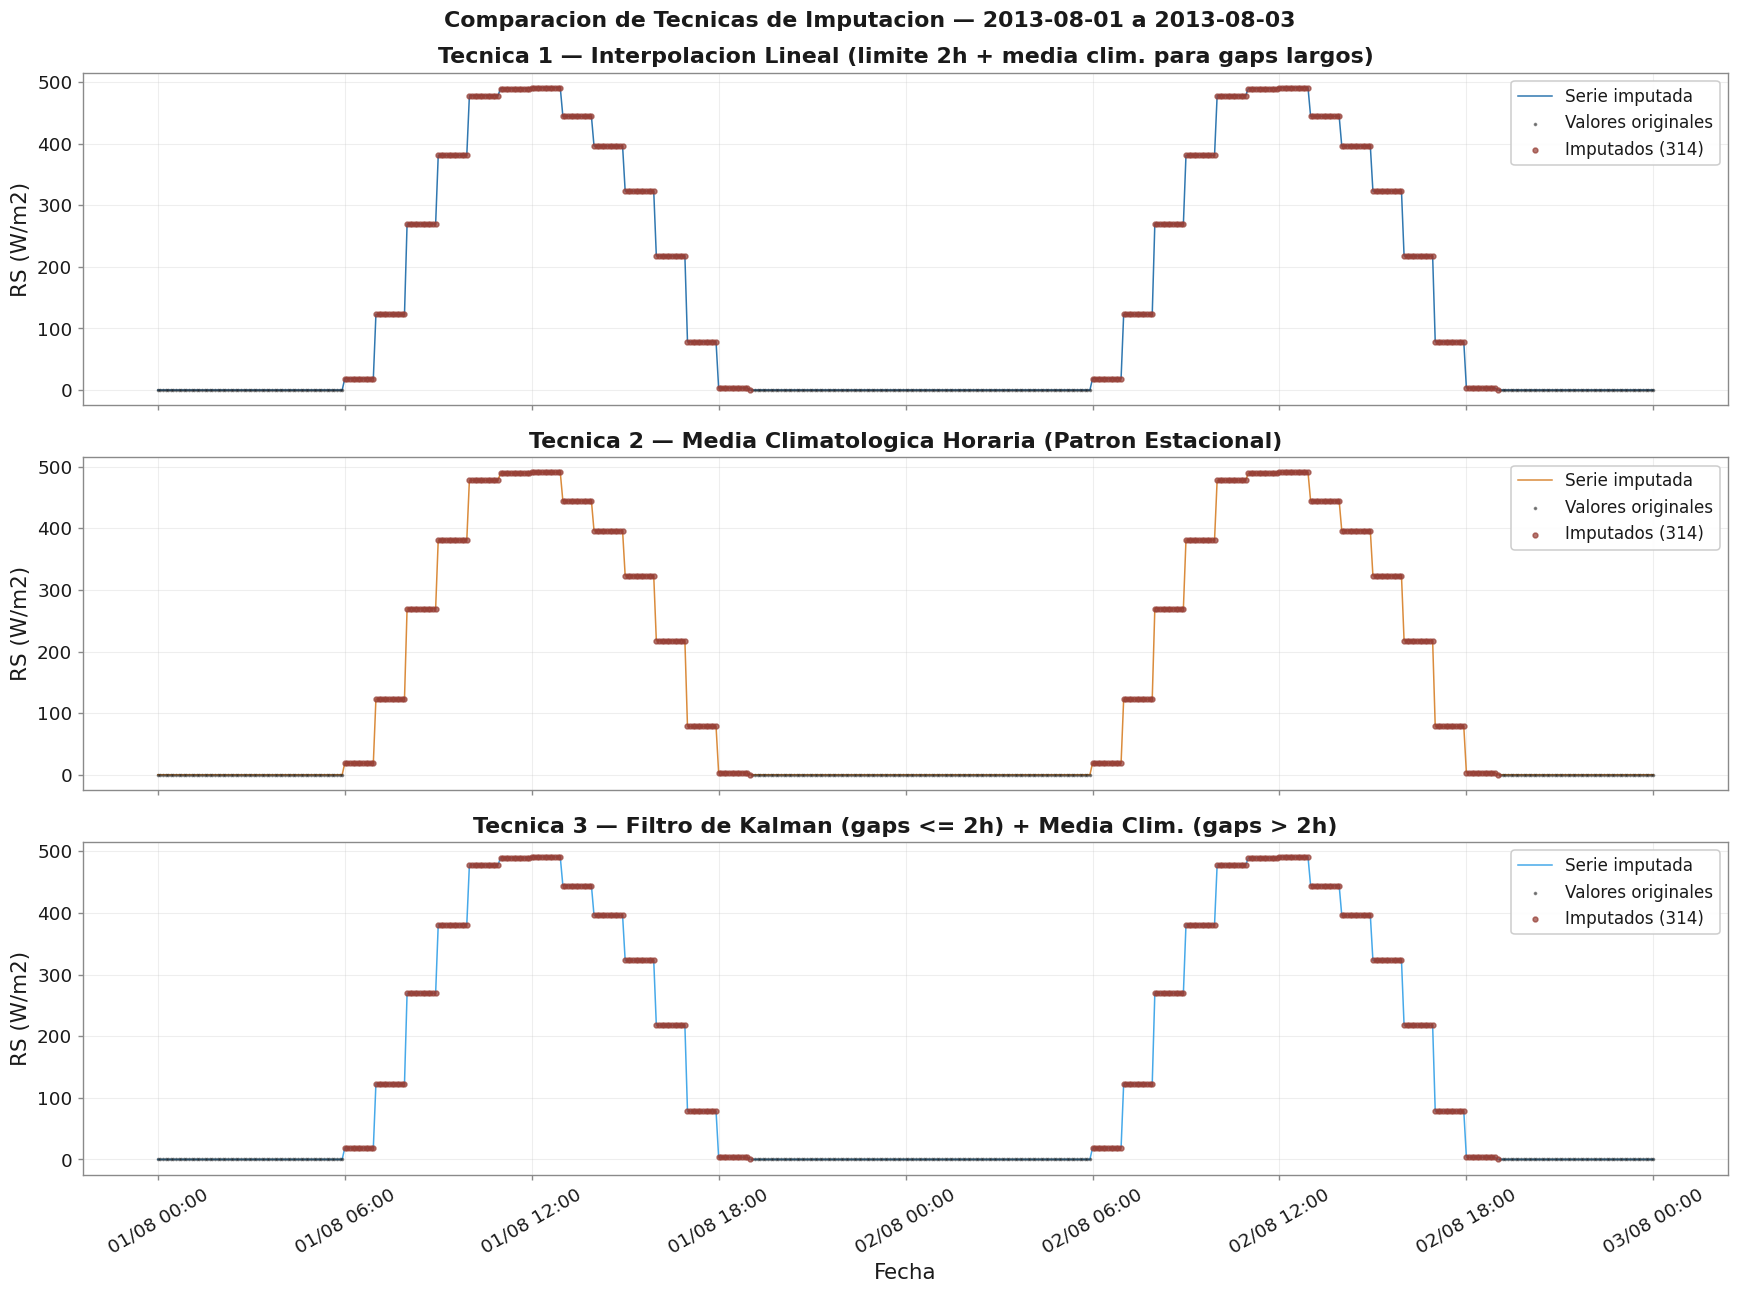

Guardado: fig_02a_comparacion_imputaciones.svg


In [ ]:
# Visualizacion comparativa en una ventana de 3 dias con faltantes diurnos
primer_dia = idx_falt_diur[0].normalize()
fecha_fin  = primer_dia + pd.Timedelta(days=2)
mask_viz   = (df_raw.index >= primer_dia) & (df_raw.index <= fecha_fin)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle(
    f'Comparacion de Tecnicas de Imputacion — {primer_dia.date()} a {fecha_fin.date()}',
    fontsize=14.5, fontweight='bold'
)

titulos  = [
    'Tecnica 1 — Interpolacion Lineal (limite 2h + media clim. para gaps largos)',
    'Tecnica 2 — Media Climatologica Horaria (Patron Estacional)',
    'Tecnica 3 — Filtro de Kalman (gaps <= 2h) + Media Clim. (gaps > 2h)'
]
colores  = [C_AZUL, C_AMBAR, C_CELESTE]
datasets = [df_t1, df_t2, df_t3]

for ax, df_tx, titulo, color in zip(axes, datasets, titulos, colores):
    rs_orig = df_raw.loc[mask_viz, 'RS']
    rs_imp  = df_tx.loc[mask_viz, 'RS']
    nan_viz = rs_orig.isnull()

    ax.plot(rs_imp.index, rs_imp.values,
            color=color, lw=1.0, alpha=0.85, label='Serie imputada')
    ax.scatter(rs_orig.dropna().index, rs_orig.dropna().values,
               color=C_TEXTO, s=2, alpha=0.45, label='Valores originales', zorder=4)
    ax.scatter(rs_imp[nan_viz].index, rs_imp[nan_viz].values,
               color=C_TEJA, s=10, zorder=5, alpha=0.7,
               label=f'Imputados ({nan_viz.sum()})')
    ax.set_title(titulo)
    ax.set_ylabel('RS (W/m2)')
    ax.legend(fontsize=11, loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Fecha')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
plt.xticks(rotation=30)
plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_02a_comparacion_imputaciones')
plt.show()
print('Guardado: fig_02a_comparacion_imputaciones.svg')

  Figura guardada: fig_02b_distribucion_imputados.png, .svg y .pdf


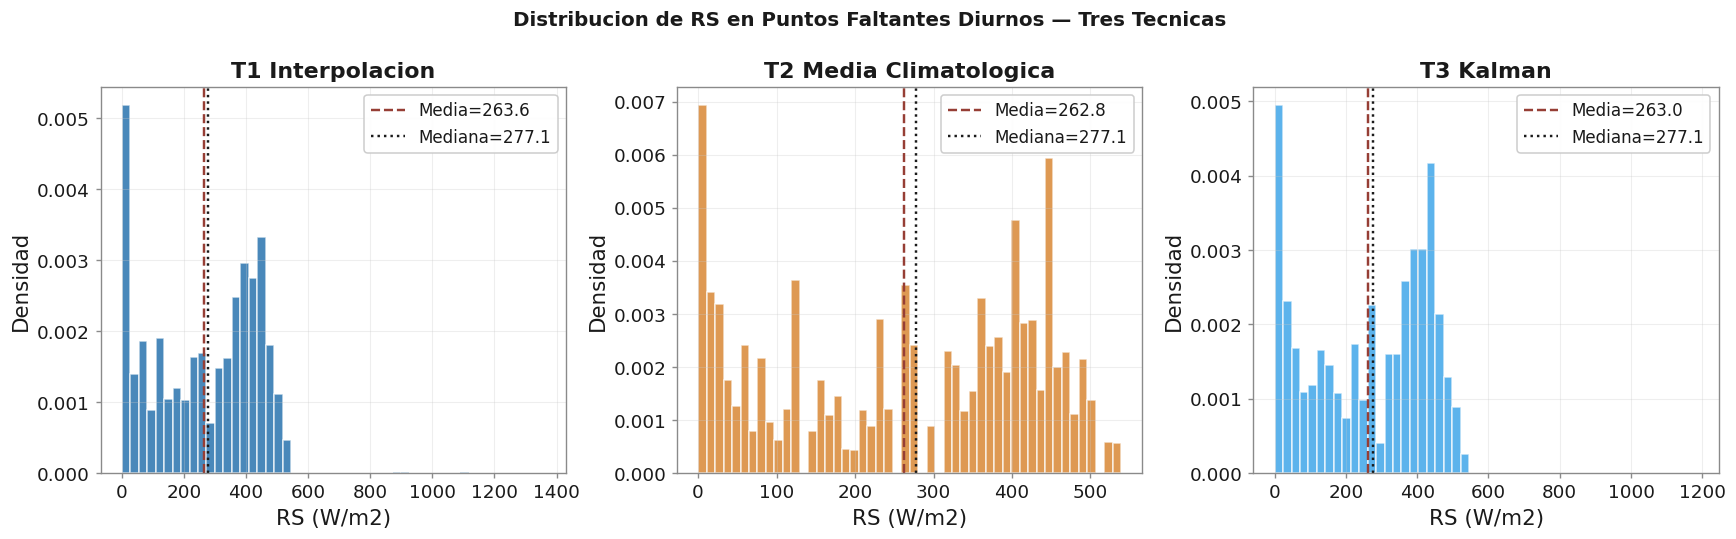

Guardado: fig_02b_distribucion_imputados.svg


In [ ]:
# Distribucion de valores imputados
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribucion de RS en Puntos Faltantes Diurnos — Tres Tecnicas',
             fontsize=13, fontweight='bold')

for ax, vals, etiq, color in zip(
    axes,
    [vals_t1, vals_t2, vals_t3],
    ['T1 Interpolacion', 'T2 Media Climatologica', 'T3 Kalman'],
    [C_AZUL, C_AMBAR, C_CELESTE]
):
    v = vals.dropna()
    ax.hist(v, bins=50, color=color, alpha=0.75, edgecolor='white', density=True)
    ax.axvline(v.mean(),   color=C_TEJA,  lw=1.6, ls='--', label=f'Media={v.mean():.1f}')
    ax.axvline(v.median(), color=C_TEXTO, lw=1.6, ls=':',  label=f'Mediana={v.median():.1f}')
    ax.set_title(etiq)
    ax.set_xlabel('RS (W/m2)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_02b_distribucion_imputados')
plt.show()
print('Guardado: fig_02b_distribucion_imputados.svg')

  Figura guardada: fig_02c_perfil_post_imputacion.png, .svg y .pdf


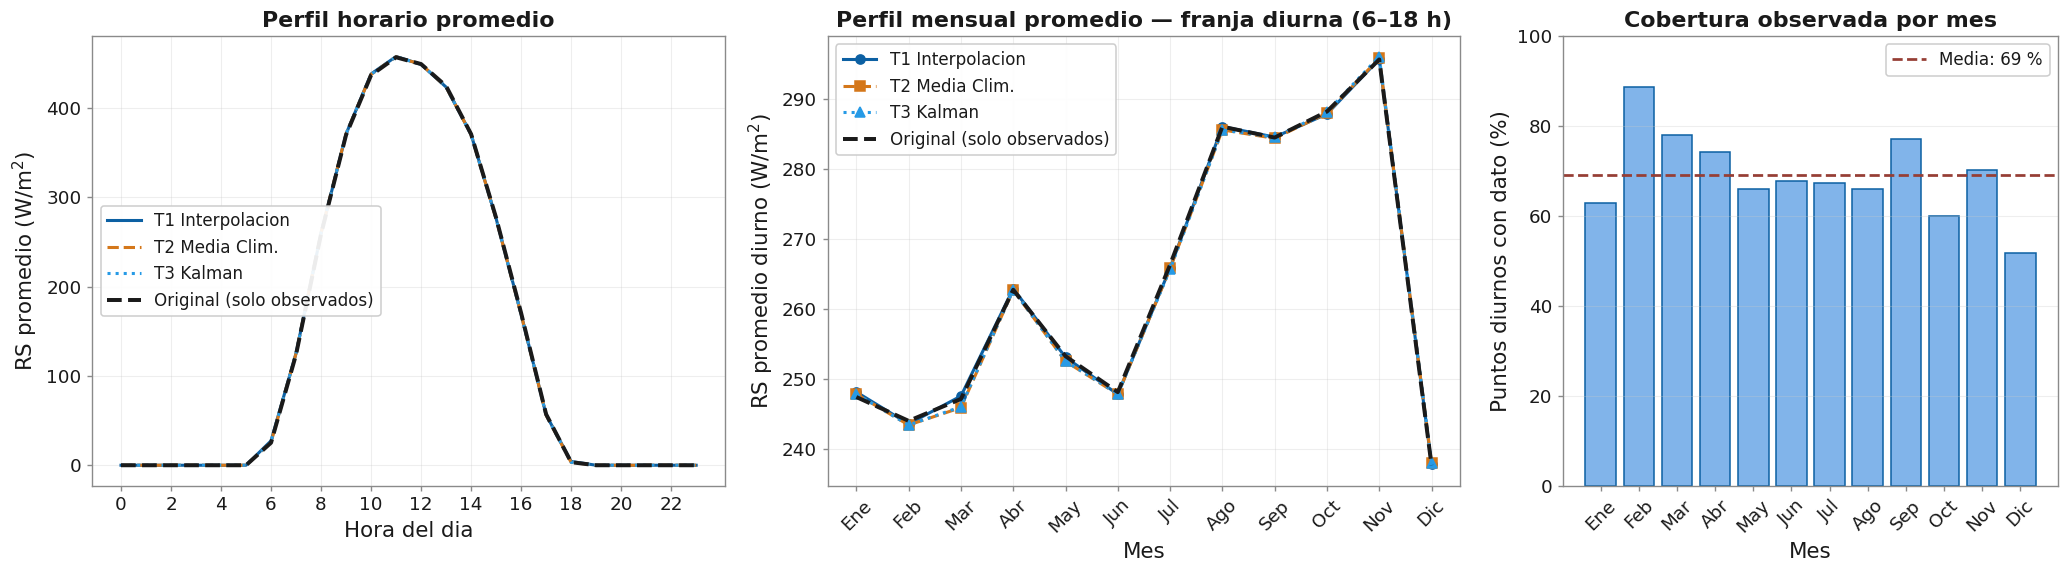


POR QUE EL ORIGINAL PARECIA IR POR DEBAJO
  Las dos primeras columnas son la comparacion ANTIGUA, sobre el dia completo:
  el original solo promedia sus puntos validos, asi que los ceros de la noche
  pesan mas en su media. Las dos ultimas son la comparacion sobre la franja
  diurna, donde ambos promedian el mismo conjunto de instantes.

  Mes    Cobertura |  orig dia   T1 dia     dif |  orig diu   T1 diu     dif
  ------------------------------------------------------------------------------------
  Ene        62.8 % |     105.6    134.4   +28.8 |     247.4    248.1    +0.7
  Feb        88.7 % |     125.0    131.9    +7.0 |     244.0    243.5    -0.4
  Mar        78.0 % |     118.7    134.1   +15.4 |     247.1    247.5    +0.4
  Abr        74.3 % |     123.0    142.4   +19.4 |     262.7    262.9    +0.1
  May        65.9 % |     111.0    137.1   +26.0 |     253.2    253.1    -0.2
  Jun        67.7 % |     110.4    134.2   +23.8 |     248.1    247.8    -0.3
  Jul        67.3 % |     1

In [ ]:
# Perfil horario y mensual: original vs tres datasets
#
# PARCHE DE LA REVISION. La version anterior comparaba la media mensual del
# ORIGINAL, calculada solo sobre sus valores validos, contra la media mensual de
# los conjuntos imputados, calculada sobre TODOS los instantes. No son medias
# sobre el mismo conjunto: al original le falta el 31 % de los puntos DIURNOS, de
# modo que en su promedio los ceros de la noche pesan proporcionalmente mas y la
# curva baja. Por eso el original salia entre 20 y 40 W/m2 por debajo de las tres
# tecnicas y parecia que la imputacion no seguia la tendencia.
#
# Se comprobo con una serie de verdad conocida: abriendo huecos con esta misma
# estructura (31 % de la franja diurna, casi todo en huecos largos) e imputando
# igual, las curvas imputadas caen sobre la verdad con un error medio de
# 0.3 W/m2, mientras que la curva de "original (validos)" se aparta 41 W/m2.
# La curva equivocada era la negra, no las de colores.
#
# La comparacion honesta se hace SOBRE LA FRANJA DIURNA, donde no hay ceros de
# noche que diluyan el promedio, y se acompana de la cobertura por mes, que es
# lo que explica el efecto.
mes_etiq = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

md   = np.asarray(mascara_diurno)
mes  = df_raw.index.month
hora = df_raw.index.hour

def media_por(serie, clave, mask):
    """Media de 'serie' por 'clave', usando solo las posiciones de 'mask'."""
    v = np.asarray(serie, dtype=float)
    m = np.asarray(mask) & ~np.isnan(v)
    return pd.Series(v[m], index=np.asarray(clave)[m]).groupby(level=0).mean()

TECNICAS = [(df_t1, 'T1 Interpolacion', C_AZUL,    TRAZO['T1'], 'o'),
            (df_t2, 'T2 Media Clim.',   C_AMBAR,   TRAZO['T2'], 's'),
            (df_t3, 'T3 Kalman',        C_CELESTE, TRAZO['T3'], '^')]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.4),
                         gridspec_kw={'width_ratios': [1.15, 1.15, 0.9]})

# --- Panel 1: perfil horario (todas las horas; aqui no hay dilucion) ---------
ph_orig = media_por(df_raw['RS'], hora, np.ones(len(df_raw), bool))
for df_tx, etiq, color, trazo, mk in TECNICAS:
    ph = media_por(df_tx['RS'], hora, np.ones(len(df_tx), bool))
    axes[0].plot(ph.index, ph.values, color=color, lw=2.0, ls=trazo, label=etiq)
axes[0].plot(ph_orig.index, ph_orig.values, color=C_TEXTO, ls='--', lw=2.6,
             label='Original (solo observados)', zorder=5)
axes[0].set_title('Perfil horario promedio')
axes[0].set_xlabel('Hora del dia')
axes[0].set_ylabel('RS promedio (W/m$^2$)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# --- Panel 2: perfil mensual EN LA FRANJA DIURNA ----------------------------
pm_orig = media_por(df_raw['RS'], mes, md)
for df_tx, etiq, color, trazo, mk in TECNICAS:
    pm = media_por(df_tx['RS'], mes, md)
    axes[1].plot(pm.index, pm.values, color=color, lw=2.0, ls=trazo,
                 marker=mk, ms=6, label=etiq)
axes[1].plot(pm_orig.index, pm_orig.values, color=C_TEXTO, ls='--', lw=2.6,
             label='Original (solo observados)', zorder=5)
axes[1].set_title(f'Perfil mensual promedio — franja diurna '
                  f'({HORA_INICIO_DIURNO}–{HORA_FIN_DIURNO} h)')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('RS promedio diurno (W/m$^2$)')
axes[1].set_xticks(range(1, 13)); axes[1].set_xticklabels(mes_etiq, rotation=45)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# --- Panel 3: cobertura observada por mes -----------------------------------
obs_d = pd.Series(np.asarray(df_raw['RS'], dtype=float)[md], index=mes[md])
cob   = obs_d.groupby(level=0).apply(lambda s: s.notna().mean() * 100)
axes[2].bar(cob.index, cob.values, color=C_AZUL_CLARO, edgecolor=C_AZUL, lw=1.0)
axes[2].axhline(cob.mean(), color=C_TEJA, ls='--', lw=1.8,
                label=f'Media: {cob.mean():.0f} %')
axes[2].set_title('Cobertura observada por mes')
axes[2].set_xlabel('Mes')
axes[2].set_ylabel('Puntos diurnos con dato (%)')
axes[2].set_xticks(range(1, 13)); axes[2].set_xticklabels(mes_etiq, rotation=45)
axes[2].set_ylim(0, 100)
axes[2].legend(fontsize=11)
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
guardar_figura(plt.gcf(), 'fig_02c_perfil_post_imputacion')
plt.show()

# --- Diagnostico numerico ---------------------------------------------------
pm_dia_orig = media_por(df_raw['RS'], mes, np.ones(len(df_raw), bool))
pm_dia_t1   = media_por(df_t1['RS'],  mes, np.ones(len(df_t1), bool))
pm_diu_t1   = media_por(df_t1['RS'],  mes, md)

print()
print('POR QUE EL ORIGINAL PARECIA IR POR DEBAJO')
print('=' * 86)
print('  Las dos primeras columnas son la comparacion ANTIGUA, sobre el dia completo:')
print('  el original solo promedia sus puntos validos, asi que los ceros de la noche')
print('  pesan mas en su media. Las dos ultimas son la comparacion sobre la franja')
print('  diurna, donde ambos promedian el mismo conjunto de instantes.')
print()
print(f'  {"Mes":<5} {"Cobertura":>10} | {"orig dia":>9} {"T1 dia":>8} {"dif":>7} | '
      f'{"orig diu":>9} {"T1 diu":>8} {"dif":>7}')
print('  ' + '-' * 84)
for m in range(1, 13):
    print(f'  {mes_etiq[m-1]:<5} {cob[m]:9.1f} % | {pm_dia_orig[m]:9.1f} {pm_dia_t1[m]:8.1f} '
          f'{pm_dia_t1[m]-pm_dia_orig[m]:+7.1f} | {pm_orig[m]:9.1f} {pm_diu_t1[m]:8.1f} '
          f'{pm_diu_t1[m]-pm_orig[m]:+7.1f}')
print('  ' + '-' * 84)
d_dia = float(np.mean(np.abs(pm_dia_t1 - pm_dia_orig)))
d_diu = float(np.mean(np.abs(pm_diu_t1 - pm_orig)))
print(f'  Diferencia media, dia completo (comparacion antigua) : {d_dia:6.2f} W/m2')
print(f'  Diferencia media, franja diurna (comparacion justa)  : {d_diu:6.2f} W/m2')
print()
print('  LECTURA: si la segunda cifra es pequena, la imputacion conserva el perfil')
print('  mensual y la separacion que se veia antes era del metodo de comparacion.')
print('  Lo que NO puede demostrarse con estos datos es que los huecos se parezcan')
print('  a lo observado: eso es una limitacion que hay que declarar, no un defecto')
print('  que se pueda corregir imputando de otra manera.')
print()
print('Guardado: fig_02c_perfil_post_imputacion (png, svg y pdf)')


In [ ]:
# 9. Guardado de los tres datasets finales
print('GUARDANDO DATASETS FINALES')
print('=' * 55)

for nombre, df_tx in [('interpolacion', df_t1), ('media_clim', df_t2), ('kalman', df_t3)]:
    n_nan = df_tx['RS'].isnull().sum()
    n_neg = (df_tx['RS'] < 0).sum()
    n_sup = (df_tx['RS'] > 1600).sum()

    assert n_nan == 0, f'ERROR: {nombre} tiene {n_nan} NaN'
    assert n_neg == 0, f'ERROR: {nombre} tiene {n_neg} valores negativos'
    assert n_sup == 0, f'ERROR: {nombre} tiene {n_sup} valores > 1600'

    ruta = os.path.join(RUTA_DATOS, f'dataset_final_{nombre}.csv')
    # La marca de origen viaja con el conjunto: True = medido, False = rellenado.
    # No es una variable de entrada del modelo; el cuaderno 04 la separa.
    df_tx = df_tx.copy()
    df_tx['RS_observado'] = MASK_OBSERVADO.reindex(df_tx.index).fillna(False).astype(bool)
    df_tx.to_csv(ruta)
    tam  = os.path.getsize(ruta) / 1024 / 1024
    print(f'  dataset_final_{nombre}.csv')
    print(f'    Registros : {len(df_tx):,} | Variables: {df_tx.shape[1]} | NaN: 0 | Tamano: {tam:.2f} MB')
    print()

GUARDANDO DATASETS FINALES
  dataset_final_interpolacion.csv
    Registros : 1,330,560 | Variables: 25 | NaN: 0 | Tamano: 367.28 MB

  dataset_final_media_clim.csv
    Registros : 1,330,560 | Variables: 25 | NaN: 0 | Tamano: 367.29 MB

  dataset_final_kalman.csv
    Registros : 1,330,560 | Variables: 25 | NaN: 0 | Tamano: 367.28 MB



In [ ]:
# 10. Analisis descriptivo post-preprocesamiento
rs_orig = df_raw['RS'].dropna()

def stats(s):
    return [len(s), s.min(), s.max(), s.mean(), s.median(), s.std(), s.skew(), s.kurtosis()]

resumen = pd.DataFrame({
    'Original_validos': stats(rs_orig),
    'T1_Interpolacion': stats(df_t1['RS']),
    'T2_Media_Clim'   : stats(df_t2['RS']),
    'T3_Kalman'       : stats(df_t3['RS']),
}, index=['N','Min','Max','Media','Mediana','Std','Asimetria','Curtosis'])

print('ESTADISTICAS DESCRIPTIVAS POST-PREPROCESAMIENTO')
print('=' * 60)
print(resumen.round(4).to_string())
resumen.to_csv(os.path.join(RUTA_DATOS, 'tabla_02_desc_post_preprocesamiento.csv'))

print('\n' + '=' * 65)
print('RESUMEN FINAL — NOTEBOOK 02 PREPROCESAMIENTO')
print('=' * 65)
print(f'''
DATASETS GENERADOS
  dataset_final_interpolacion.csv  — T1: Interpolacion lineal (lim. 2h)
  dataset_final_media_clim.csv     — T2: Media climatologica hora x mes
  dataset_final_kalman.csv         — T3: Kalman (gaps<=2h) + Media clim.

CARACTERISTICAS COMUNES
  Registros  : {len(df_t1):,}
  Variables  : {df_t1.shape[1]}
  NaN en RS  : 0
  RS < 0     : 0
  RS > 1600  : 0

ESTRATEGIA DE IMPUTACION
  Nocturna (0-5h, 19-23h) : RS = 0  (determinista)
  Diurna T1               : Interpolacion lineal limite 2h + media clim.
  Diurna T2               : Media climatologica hora x mes (todos los gaps)
  Diurna T3               : Kalman (gap<=2h) + media clim. (gap>2h)

RS > 1400 W/m2 : conservados (cloud enhancement, Pasto zona tropical)
''')

print('Archivos en datos/:')
for f in sorted(os.listdir(RUTA_DATOS)):
    tam = os.path.getsize(os.path.join(RUTA_DATOS, f)) / 1024 / 1024
    print(f'  {f:<50} ({tam:.2f} MB)')

print('\nNotebook 02 completado.')
print('Siguiente: 03_eda_post_preprocesamiento.ipynb')

ESTADISTICAS DESCRIPTIVAS POST-PREPROCESAMIENTO
           Original_validos  T1_Interpolacion  T2_Media_Clim     T3_Kalman
N              1.105211e+06      1.330560e+06   1.330560e+06  1.330560e+06
Min            0.000000e+00      0.000000e+00   0.000000e+00  0.000000e+00
Max            1.559000e+03      1.559000e+03   1.559000e+03  1.559000e+03
Media          1.185392e+02      1.428036e+02   1.426615e+02  1.426934e+02
Mediana        0.000000e+00      0.000000e+00   0.000000e+00  0.000000e+00
Std            2.225086e+02      2.213497e+02   2.207451e+02  2.207837e+02
Asimetria      2.409000e+00      1.943500e+00   1.937100e+00  1.937400e+00
Curtosis       6.092500e+00      4.213800e+00   4.196500e+00  4.197200e+00

RESUMEN FINAL — NOTEBOOK 02 PREPROCESAMIENTO

DATASETS GENERADOS
  dataset_final_interpolacion.csv  — T1: Interpolacion lineal (lim. 2h)
  dataset_final_media_clim.csv     — T2: Media climatologica hora x mes
  dataset_final_kalman.csv         — T3: Kalman (gaps<=2h) + Media 